In [1]:
from datetime import time
from os import times
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as patches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import math
from cartopy.mpl.ticker import LongitudeFormatter,LatitudeFormatter

#math的相关函数，import后可以直接使用
from math import radians
from math import sin
from math import cos
from math import asin
from math import sqrt

# np.set_printoptions(threshold=np.inf)#显示所有的数组
from geopy.distance import great_circle
import matplotlib
# matplotlib.rcParams['font.family'] = 'Times New Roman'
import seaborn as sns
from scipy import stats

In [2]:
infile = xr.open_dataset('D:/data/ibtracs/IBTrACS.WP.v04r01.nc')


# In[4]:


stayyy=1949
endyyy=2024
censea=infile['season']
indsea=np.where((censea>=stayyy)&(censea<=endyyy))
numsea=censea[indsea]


# In[5]:


tim=infile['time']
centim=tim.dt.month[:,0]
indtim=np.where((centim==7)|(centim==8)|(centim==9)|(centim==10))
numtim=tim[indtim]


# In[6]:


centyp=infile['track_type']
indtyp=np.where(centyp==b'main')
numtyp=centyp[indtyp]


# In[7]:


cenlat=infile['usa_lat']
nummia=np.sum(np.isnan(cenlat), axis=1)
numnma=np.sum(~np.isnan(cenlat), axis=1)  
minlat=np.amin(cenlat, axis=1)
minlat=np.amin(cenlat, axis=1)
indlat=np.where(numnma>=16)
numlat=cenlat[indlat]


# In[8]:


cenlon=infile['usa_lon']
nummio=np.sum(np.isnan(cenlon), axis=1) 
numnmo=np.sum(~np.isnan(cenlon), axis=1)  
minlon=np.amin(cenlon, axis=1)  
maxlon=np.amax(cenlon, axis=1) 
indlon=np.where(numnmo>=16)
numlon=cenlon[indlon]


# In[9]:


cenwin=infile['usa_wind']
nummiw=np.sum(np.isnan(cenwin), axis=1)   #每行nan个数
numnmw=np.sum(~np.isnan(cenwin), axis=1)  
maxwin = np.amax(cenwin, axis=1) 
indmaw = np.where(maxwin>=35) 
indwin = np.where((numnmw>=16)&(maxwin>=35))
numwin =cenwin[indwin]
# numwin


# In[10]:


cenatu=infile['nature']
numnat= np.sum(np.isin(cenatu, [b'DS', b'ET']), axis=1)#有多少个DS,ET,要这俩=0的地方
numb=np.sum(cenatu != b'', axis=1)#非空值的个数，用于去除空值以及小于48小时的情况,numb>16,3h
indnat=np.where((numb!=numnat)&(numb>16))


# In[11]:


lat = infile['usa_lat']

# 创建布尔掩码以筛选7、8、9月份的数据
mask = lat['time'].dt.month.isin([7, 8, 9])

# 保留掩码对应的数据并将其他数据设为NaN
lat2 = lat.where(mask, drop=True)

# 打印筛选后的数据以检查结果
# print(lat2)


# ## 登陆landindall_flat

# In[12]:


cendis=infile['dist2land']
nummid=np.sum(np.isnan(cendis), axis=1)   
numnmd=np.sum(~np.isnan(cendis), axis=1)  #非nan数
num0md=np.sum(cendis==0, axis=1) #每行几个0
inddis=np.where((numnmd>=16)&(num0md>0))  #0代表登陆，看有几个0
numdis=cendis[inddis]#登录的结果
landindall=[]
landindallin=[]
for j in range(1982,2024):  
    indall = np.where((censea==j)
                    &(centyp==b'main')
                    &((centim==7)|(centim==8)|(centim==9)|(centim==10))
                    &(numnma>=16)
                    &(numnmo>=16)
                    &((numnmw>=16)&(maxwin>=35))
                    &((numb!=numnat)&(numb>=16))
                    &((numnmd>=16)&(num0md>0)))
    landindall.append(indall[0])
landindall_flat = np.concatenate(landindall).tolist()  # 将所有数组拼接并转换为列表


In [3]:
import numpy as np
import matplotlib.pyplot as plt

def plot_change_data(years, data, ylabel, title, split_index):
    """
    根据输入的年份、数据、分割点、纵坐标标签和图表标题绘制折线图，并标注前后平均值横线。
    
    Parameters:
    years (array-like): 年份序列。
    data (array-like): 对应年份的数值数据。
    ylabel (str): 纵坐标的标签。
    title (str): 图表的标题。
    split_index (int): 数据分割点，用于划分前后部分。
    """
    # 计算分割点之前和之后的平均值
    avg_prior = np.mean(data[:split_index])
    avg_post = np.mean(data[split_index:])
    
    # 绘制数据点及连线
    plt.plot(years, data, '-o', color='red')
    
    # 绘制分割点之前数据的平均值横线
    plt.plot(years[:split_index], [avg_prior] * split_index, color='blue', linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')
    
    # 绘制分割点之后数据的平均值横线
    plt.plot(years[split_index:], [avg_post] * (len(years) - split_index), color='blue', linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
    
    # 添加坐标标签和标题
    plt.xlabel('Year', fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.title(title,loc='left',fontsize=12)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    
    
    # 添加图例
    plt.legend(loc=1)

    
    P1 = data[:split_index]
    P2 =  data[split_index:]

    # 执行独立样本t检验，默认假设方差不等
    t_stat, p_value = stats.ttest_ind(P1, P2, equal_var=False)

    plt.title(f't: {t_stat:.2f}, P: {p_value:.2f}',loc='right',fontsize=12)
#     plt.text(1992, 1.05, f"Slope: {slope:.3f} ± {std_err:.3f}  per decade", fontsize=12, color='black')
    
    plt.show()
# split_index = 16  # 设置分割点为前16年和后24年
# plot_change_data(years, tomecur_totle, 'dist/km', 'Dist over Years', 17)


In [4]:
years = np.arange(1982, 2024)
split_index=17

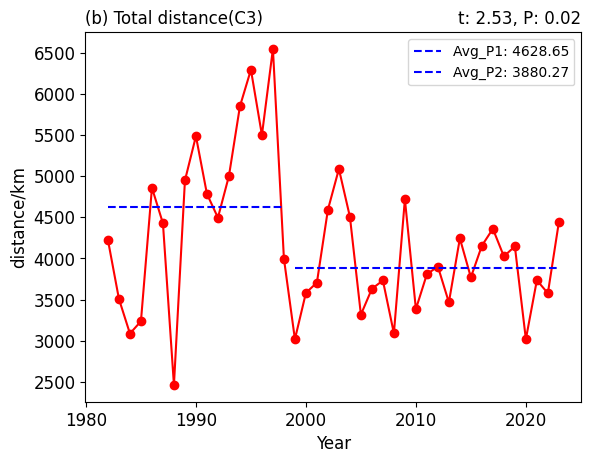

In [5]:
df = pd.read_excel(f'Typhoon_Cluster_3.xlsx')



tomecur = []

for year in range(1982, 2024):  # 包括1982到2023年
    # 提取当前年份的数据
    year_data = df[df['year'] == year]
    
    # 获取该年份所有的 Typhoon ID，并去掉 3020
    indall = year_data['Typhoon ID'].unique()
    numatc = indall.shape[0]

   
 
    lat=infile['usa_lat'][indall]#筛选的结果
    lon=infile['usa_lon'][indall]   
    win=infile['usa_wind'][indall]
    tocur=[]
    for i in range(0,numatc):#一年的登陆台风曲率
        arrlat= np.array([num for num in lat[i].values if not np.isnan(num)])#将非nan存在新的数组中,一个新的数组
        arrlon= np.array([num for num in lon[i].values if not np.isnan(num)])
        arrwin= np.array([num for num in win[i].values if not np.isnan(num)])
        orilat=arrlat[0]
        endlat=arrlat[-1]
        
        orilon=arrlon[0]
        endlon=arrlon[-1]
       
        ori=[orilat,orilon]#起点集合
        end=[endlat,endlon]
        dist=great_circle(ori, end).kilometers#起点和终点的距离
        if dist!=0:
        
            coor=np.column_stack((arrlat, arrlon))#合并经纬度
            todist=0#总距离todist
            for k in range(len(coor) - 1):
                distall = great_circle(coor[k], coor[k+1]).kilometers
                todist += distall
            cur=todist
#             if cur<4.96:
                
            
           
            tocur.append(cur)
   
    mecur=np.mean(tocur)#平均曲率
    tomecur.append(mecur)

        
    
totaldistance = tomecur

plot_change_data(years,totaldistance, 'distance/km', '(b) Total distance(C3)', 17)


In [6]:
totaldistance

[np.float64(4222.362032647359),
 np.float64(3507.525682935357),
 np.float64(3087.224039796603),
 np.float64(3237.3044284911452),
 np.float64(4858.224492112573),
 np.float64(4425.974038211399),
 np.float64(2463.830086869901),
 np.float64(4946.148970732411),
 np.float64(5484.290290837733),
 np.float64(4783.703592082133),
 np.float64(4494.173656232167),
 np.float64(5000.147291289794),
 np.float64(5846.439646556389),
 np.float64(6290.807399645988),
 np.float64(5497.408099269562),
 np.float64(6543.531741424866),
 np.float64(3998.031399098332),
 np.float64(3018.993492174877),
 np.float64(3581.083018593254),
 np.float64(3706.531917991421),
 np.float64(4590.641882560125),
 np.float64(5086.104800362344),
 np.float64(4506.155457068017),
 np.float64(3317.181734112056),
 np.float64(3631.03936880132),
 np.float64(3732.239592077211),
 np.float64(3090.2196677987467),
 np.float64(4718.408444210579),
 np.float64(3384.8801519272133),
 np.float64(3808.2412056573485),
 np.float64(3901.3917685534575),
 np.

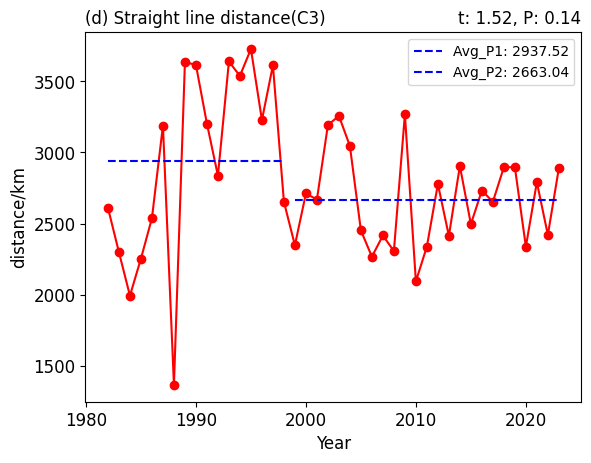

In [7]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# 读取数据
df = pd.read_excel(f'Typhoon_Cluster_3.xlsx')

# 要去掉的 Typhoon ID
exclude_id = 3020

tomecur = []

for year in range(1982, 2024):  # 包括1982到2023年
    # 提取当前年份的数据
    year_data = df[df['year'] == year]
    
    # 获取该年份所有的 Typhoon ID，并去掉 3020
    indall = year_data['Typhoon ID'].unique()
    indall = np.array([id for id in indall if id != exclude_id])  # 去掉 Typhoon ID 3020
    numatc = indall.shape[0]

   
 
    lat=infile['usa_lat'][indall]#筛选的结果
    lon=infile['usa_lon'][indall]   
    win=infile['usa_wind'][indall]
    tocur=[]
    for i in range(0,numatc):#一年的登陆台风曲率
        arrlat= np.array([num for num in lat[i].values if not np.isnan(num)])#将非nan存在新的数组中,一个新的数组
        arrlon= np.array([num for num in lon[i].values if not np.isnan(num)])
        arrwin= np.array([num for num in win[i].values if not np.isnan(num)])
        orilat=arrlat[0]
        endlat=arrlat[-1]
        
        orilon=arrlon[0]
        endlon=arrlon[-1]
       
        ori=[orilat,orilon]#起点集合
        end=[endlat,endlon]
        dist=great_circle(ori, end).kilometers#起点和终点的距离
        if dist!=0:
        
            coor=np.column_stack((arrlat, arrlon))#合并经纬度
            todist=0#总距离todist
            for k in range(len(coor) - 1):
                distall = great_circle(coor[k], coor[k+1]).kilometers
                todist += distall
            cur=dist
#             if cur<4.96:
                
            
           
            tocur.append(cur)
   
    mecur=np.mean(tocur)#平均曲率
    tomecur.append(mecur)


linedistance = tomecur

plot_change_data(years,linedistance, 'distance/km', '(d) Straight line distance(C3)', 17)


In [8]:
linedistance

[np.float64(2610.7661798317336),
 np.float64(2298.083636125538),
 np.float64(1993.2416431763647),
 np.float64(2253.4409596846713),
 np.float64(2538.2620541494275),
 np.float64(3189.1636528934496),
 np.float64(1365.6556746994331),
 np.float64(3635.4153330680706),
 np.float64(3615.5475816885573),
 np.float64(3202.5091888108136),
 np.float64(2836.446537000295),
 np.float64(3639.555376700047),
 np.float64(3538.1734291260364),
 np.float64(3727.9615091439587),
 np.float64(3227.9799253961573),
 np.float64(3612.7408759533037),
 np.float64(2652.8235968070694),
 np.float64(2348.0134379874303),
 np.float64(2711.58701476081),
 np.float64(2668.88629338314),
 np.float64(3192.324722078831),
 np.float64(3257.579575723436),
 np.float64(3045.5604922953353),
 np.float64(2452.020243235858),
 np.float64(2267.130688135969),
 np.float64(2416.2529087594958),
 np.float64(2306.629226855868),
 np.float64(3267.892485353292),
 np.float64(2093.383903440544),
 np.float64(2338.8401271995153),
 np.float64(2777.9885314

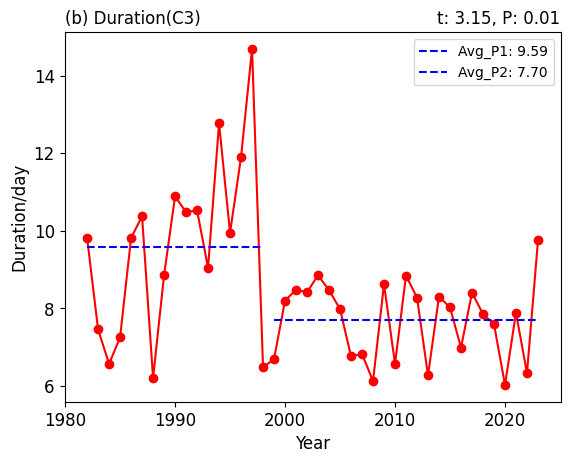

In [9]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# 读取数据
df = pd.read_excel(f'Typhoon_Cluster_3.xlsx')



tomecur1 = []
tonccur = []

for year in range(1982, 2024):  # 包括1982到2023年
    # 提取当前年份的数据
    year_data = df[df['year'] == year]
    
    # 获取该年份所有的 Typhoon ID，并去掉 3020
    indall = year_data['Typhoon ID'].unique()
   
    numatc = indall.shape[0]

    lat = infile['usa_lat'][indall]  # 筛选的结果
    lon = infile['usa_lon'][indall]
    tocur = []
    
    for i in range(0, numatc):  # 一年的登陆台风曲率
        arrlat = np.array([num for num in lat[i].values if not np.isnan(num)])  # 将非nan存在新的数组中
        arrlon = np.array([num for num in lon[i].values if not np.isnan(num)])
        dura = (arrlat.shape[0] - 1) / 8
        cur = dura
        tocur.append(cur)
    
    mecur = np.mean(tocur)  # 平均曲率
    tomecur1.append(mecur)  # 40年平均曲率
    
c3duration = tomecur1

plot_change_data(years, c3duration, 'Duration/day', '(b) Duration(C3)', 17)

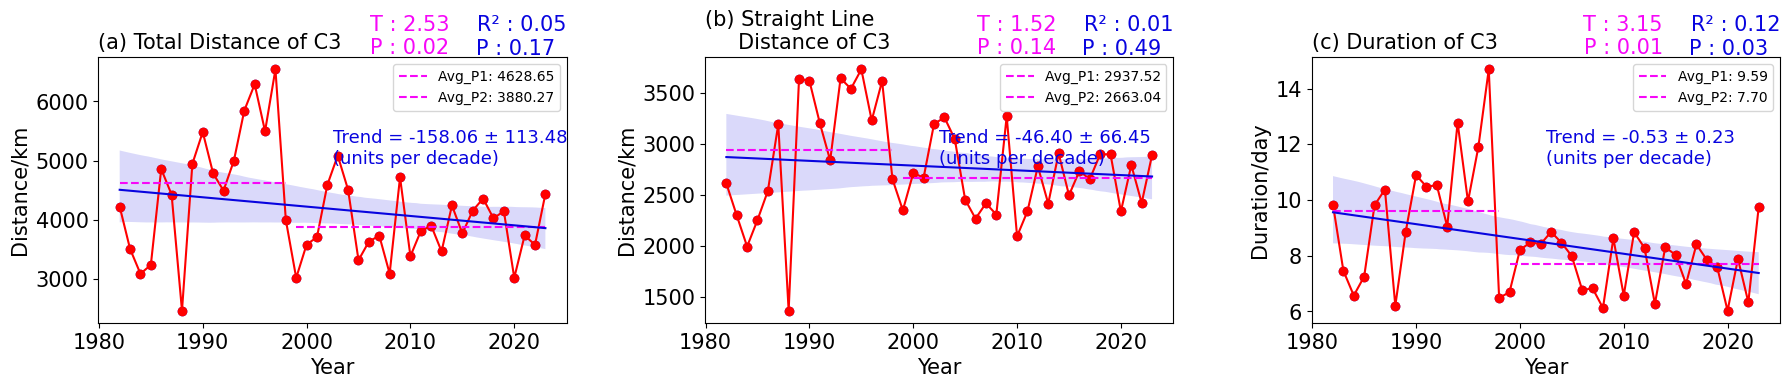

In [10]:
split_index=17
x=years
color3='#f608f8'
color1='r'
color2='#0804df'
fig, axes = plt.subplots(1,3, figsize=(18, 4))
# fig.subplots_adjust(top=1,bottom=0,left=0,right=1,hspace=0.4)
ax=axes[0]
data=totaldistance
avg_prior = np.mean(data[:split_index])
avg_post = np.mean(data[split_index:])
ax.plot(years, data, '-o', color='red')
ax.plot(years[:split_index], [avg_prior] * split_index, color=color3, linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')
ax.plot(years[split_index:], [avg_post] * (len(years) - split_index), color=color3, linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
ax.set_xlabel('Year', fontsize=15)
ax.set_ylabel('Distance/km', fontsize=15)
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)
ax.legend(loc=1)
P1 = data[:split_index]
P2 =  data[split_index:]
t_stat, p_value2 = stats.ttest_ind(P1, P2, equal_var=False)
ax.set_title('(a) Total Distance of C3',loc='left',fontsize=15)
x=years
y=data
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value ** 2
sns.regplot(x=x, y=y, ci=95,color=color2,ax=ax, line_kws={"linewidth": 1.5})
trend_per_century = slope * 10
std_err_per_century = std_err * 10  # 将标准误差转换为每世纪的不确定性
ax.text(0.5,0.6,f"Trend = {trend_per_century:.2f} ± {std_err_per_century:.2f} \n(units per decade)",
        fontsize=13,c=color2,
       transform=ax.transAxes)
ax.text(0.75, 1.16, f'T : {t_stat:.2f}\nP : {p_value2:.2f}', ha='right', va='top', fontsize=15, color=color3, transform=ax.transAxes)
ax.text(1, 1.16, f'R² : {r_squared:.2f}', 
        ha='right', va='top', fontsize=15, color=color2, transform=ax.transAxes)
ax.text(0.975, 1.07, f'P : {p_value:.2f}', 
        ha='right', va='top', fontsize=15, color=color2, transform=ax.transAxes)




ax=axes[1]
data=linedistance
avg_prior = np.mean(data[:split_index])
avg_post = np.mean(data[split_index:])
ax.plot(years, data, '-o', color='red')
ax.plot(years[:split_index], [avg_prior] * split_index, color=color3, linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')
ax.plot(years[split_index:], [avg_post] * (len(years) - split_index), color=color3, linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
ax.set_xlabel('Year', fontsize=15)
ax.set_ylabel('Distance/km', fontsize=15)
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)
ax.legend(loc=1)
P1 = data[:split_index]
P2 =  data[split_index:]
t_stat, p_value2 = stats.ttest_ind(P1, P2, equal_var=False)
ax.set_title('(b) Straight Line \n     Distance of C3',loc='left',fontsize=15)
x=years
y=data
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value ** 2
sns.regplot(x=x, y=y, ci=95,color=color2,ax=ax, line_kws={"linewidth": 1.5})
trend_per_century = slope * 10
std_err_per_century = std_err * 10  # 将标准误差转换为每世纪的不确定性
ax.text(0.5,0.6,f"Trend = {trend_per_century:.2f} ± {std_err_per_century:.2f} \n(units per decade)",
        fontsize=13,c=color2,
       transform=ax.transAxes)
ax.text(0.75, 1.16, f'T : {t_stat:.2f}\nP : {p_value2:.2f}', ha='right', va='top', fontsize=15, color=color3, transform=ax.transAxes)
ax.text(1, 1.16, f'R² : {r_squared:.2f}', 
        ha='right', va='top', fontsize=15, color=color2, transform=ax.transAxes)
ax.text(0.975, 1.07, f'P : {p_value:.2f}', 
        ha='right', va='top', fontsize=15, color=color2, transform=ax.transAxes)




ax=axes[2]
data=c3duration
avg_prior = np.mean(data[:split_index])
avg_post = np.mean(data[split_index:])
ax.plot(years, data, '-o', color='red')
ax.plot(years[:split_index], [avg_prior] * split_index, color=color3, linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')
ax.plot(years[split_index:], [avg_post] * (len(years) - split_index), color=color3, linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
ax.set_xlabel('Year', fontsize=15)
ax.set_ylabel('Duration/day', fontsize=15)
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)
ax.legend(loc=1)
P1 = data[:split_index]
P2 =  data[split_index:]
t_stat, p_value2 = stats.ttest_ind(P1, P2, equal_var=False)
ax.set_title('(c) Duration of C3',loc='left',fontsize=15)
x=years
y=data
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value ** 2
sns.regplot(x=x, y=y, ci=95,color=color2,ax=ax, line_kws={"linewidth": 1.5})
trend_per_century = slope * 10
std_err_per_century = std_err * 10  # 将标准误差转换为每世纪的不确定性
ax.text(0.5,0.6,f"Trend = {trend_per_century:.2f} ± {std_err_per_century:.2f} \n(units per decade)",
        fontsize=13,c=color2,
       transform=ax.transAxes)
ax.text(0.75, 1.16, f'T : {t_stat:.2f}\nP : {p_value2:.2f}', ha='right', va='top', fontsize=15, color=color3, transform=ax.transAxes)
ax.text(1, 1.16, f'R² : {r_squared:.2f}', 
        ha='right', va='top', fontsize=15, color=color2, transform=ax.transAxes)
ax.text(0.975, 1.07, f'P : {p_value:.2f}', 
        ha='right', va='top', fontsize=15, color=color2, transform=ax.transAxes)


plt.tight_layout()
plt.savefig("Figure S4.pdf",transparent = True)
plt.show()

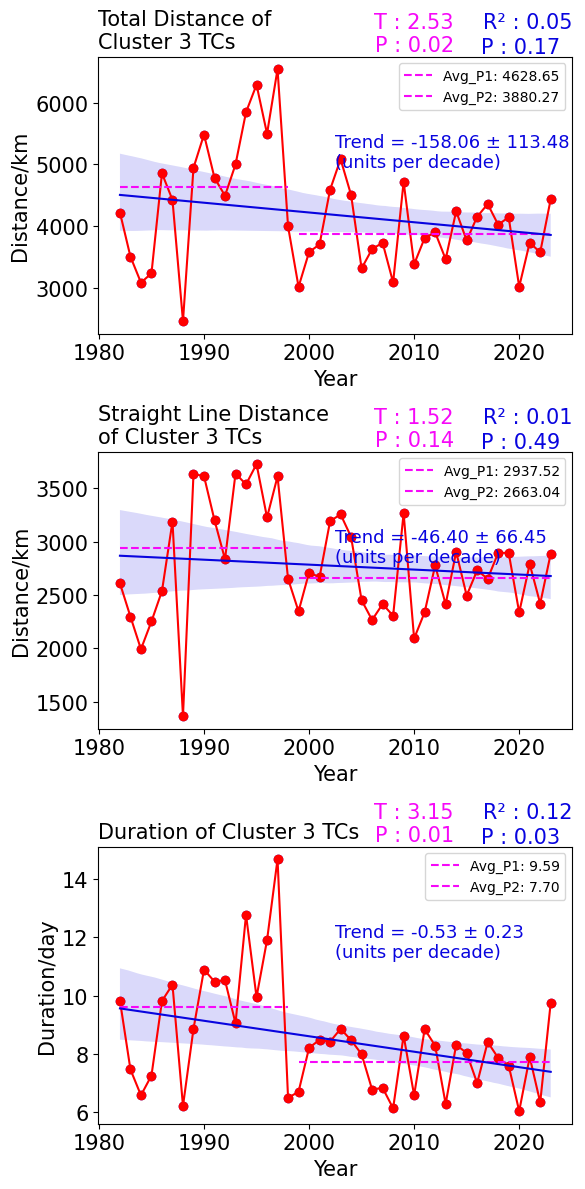

In [11]:
split_index=17
x=years
color3='#f608f8'
color1='r'
color2='#0804df'
fig, axes = plt.subplots(3,1, figsize=(6, 12))
# fig.subplots_adjust(top=1,bottom=0,left=0,right=1,hspace=0.4)
ax=axes[0]
data=totaldistance
avg_prior = np.mean(data[:split_index])
avg_post = np.mean(data[split_index:])
ax.plot(years, data, '-o', color='red')
ax.plot(years[:split_index], [avg_prior] * split_index, color=color3, linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')
ax.plot(years[split_index:], [avg_post] * (len(years) - split_index), color=color3, linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
ax.set_xlabel('Year', fontsize=15)
ax.set_ylabel('Distance/km', fontsize=15)
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)
ax.legend(loc=1)
P1 = data[:split_index]
P2 =  data[split_index:]
t_stat, p_value2 = stats.ttest_ind(P1, P2, equal_var=False)
ax.set_title('Total Distance of \nCluster 3 TCs',loc='left',fontsize=15)
x=years
y=data
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value ** 2
sns.regplot(x=x, y=y, ci=95,color=color2,ax=ax, line_kws={"linewidth": 1.5})
trend_per_century = slope * 10
std_err_per_century = std_err * 10  # 将标准误差转换为每世纪的不确定性
ax.text(0.5,0.6,f"Trend = {trend_per_century:.2f} ± {std_err_per_century:.2f} \n(units per decade)",
        fontsize=13,c=color2,
       transform=ax.transAxes)
ax.text(0.75, 1.16, f'T : {t_stat:.2f}\nP : {p_value2:.2f}', ha='right', va='top', fontsize=15, color=color3, transform=ax.transAxes)
ax.text(1, 1.16, f'R² : {r_squared:.2f}', 
        ha='right', va='top', fontsize=15, color=color2, transform=ax.transAxes)
ax.text(0.975, 1.07, f'P : {p_value:.2f}', 
        ha='right', va='top', fontsize=15, color=color2, transform=ax.transAxes)




ax=axes[1]
data=linedistance
avg_prior = np.mean(data[:split_index])
avg_post = np.mean(data[split_index:])
ax.plot(years, data, '-o', color='red')
ax.plot(years[:split_index], [avg_prior] * split_index, color=color3, linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')
ax.plot(years[split_index:], [avg_post] * (len(years) - split_index), color=color3, linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
ax.set_xlabel('Year', fontsize=15)
ax.set_ylabel('Distance/km', fontsize=15)
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)
ax.legend(loc=1)
P1 = data[:split_index]
P2 =  data[split_index:]
t_stat, p_value2 = stats.ttest_ind(P1, P2, equal_var=False)
ax.set_title('Straight Line Distance \nof Cluster 3 TCs',loc='left',fontsize=15)
x=years
y=data
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value ** 2
sns.regplot(x=x, y=y, ci=95,color=color2,ax=ax, line_kws={"linewidth": 1.5})
trend_per_century = slope * 10
std_err_per_century = std_err * 10  # 将标准误差转换为每世纪的不确定性
ax.text(0.5,0.6,f"Trend = {trend_per_century:.2f} ± {std_err_per_century:.2f} \n(units per decade)",
        fontsize=13,c=color2,
       transform=ax.transAxes)
ax.text(0.75, 1.16, f'T : {t_stat:.2f}\nP : {p_value2:.2f}', ha='right', va='top', fontsize=15, color=color3, transform=ax.transAxes)
ax.text(1, 1.16, f'R² : {r_squared:.2f}', 
        ha='right', va='top', fontsize=15, color=color2, transform=ax.transAxes)
ax.text(0.975, 1.07, f'P : {p_value:.2f}', 
        ha='right', va='top', fontsize=15, color=color2, transform=ax.transAxes)




ax=axes[2]
data=c3duration
avg_prior = np.mean(data[:split_index])
avg_post = np.mean(data[split_index:])
ax.plot(years, data, '-o', color='red')
ax.plot(years[:split_index], [avg_prior] * split_index, color=color3, linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')
ax.plot(years[split_index:], [avg_post] * (len(years) - split_index), color=color3, linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
ax.set_xlabel('Year', fontsize=15)
ax.set_ylabel('Duration/day', fontsize=15)
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)
ax.legend(loc=1)
P1 = data[:split_index]
P2 =  data[split_index:]
t_stat, p_value2 = stats.ttest_ind(P1, P2, equal_var=False)
ax.set_title('Duration of Cluster 3 TCs',loc='left',fontsize=15)
x=years
y=data
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value ** 2
sns.regplot(x=x, y=y, ci=95,color=color2,ax=ax, line_kws={"linewidth": 1.5})
trend_per_century = slope * 10
std_err_per_century = std_err * 10  # 将标准误差转换为每世纪的不确定性
ax.text(0.5,0.6,f"Trend = {trend_per_century:.2f} ± {std_err_per_century:.2f} \n(units per decade)",
        fontsize=13,c=color2,
       transform=ax.transAxes)
ax.text(0.75, 1.16, f'T : {t_stat:.2f}\nP : {p_value2:.2f}', ha='right', va='top', fontsize=15, color=color3, transform=ax.transAxes)
ax.text(1, 1.16, f'R² : {r_squared:.2f}', 
        ha='right', va='top', fontsize=15, color=color2, transform=ax.transAxes)
ax.text(0.975, 1.07, f'P : {p_value:.2f}', 
        ha='right', va='top', fontsize=15, color=color2, transform=ax.transAxes)


plt.tight_layout()
plt.savefig("Figure S8.pdf",transparent = True)
plt.show()

In [12]:
linedistance

[np.float64(2610.7661798317336),
 np.float64(2298.083636125538),
 np.float64(1993.2416431763647),
 np.float64(2253.4409596846713),
 np.float64(2538.2620541494275),
 np.float64(3189.1636528934496),
 np.float64(1365.6556746994331),
 np.float64(3635.4153330680706),
 np.float64(3615.5475816885573),
 np.float64(3202.5091888108136),
 np.float64(2836.446537000295),
 np.float64(3639.555376700047),
 np.float64(3538.1734291260364),
 np.float64(3727.9615091439587),
 np.float64(3227.9799253961573),
 np.float64(3612.7408759533037),
 np.float64(2652.8235968070694),
 np.float64(2348.0134379874303),
 np.float64(2711.58701476081),
 np.float64(2668.88629338314),
 np.float64(3192.324722078831),
 np.float64(3257.579575723436),
 np.float64(3045.5604922953353),
 np.float64(2452.020243235858),
 np.float64(2267.130688135969),
 np.float64(2416.2529087594958),
 np.float64(2306.629226855868),
 np.float64(3267.892485353292),
 np.float64(2093.383903440544),
 np.float64(2338.8401271995153),
 np.float64(2777.9885314

In [13]:
totaldistance

[np.float64(4222.362032647359),
 np.float64(3507.525682935357),
 np.float64(3087.224039796603),
 np.float64(3237.3044284911452),
 np.float64(4858.224492112573),
 np.float64(4425.974038211399),
 np.float64(2463.830086869901),
 np.float64(4946.148970732411),
 np.float64(5484.290290837733),
 np.float64(4783.703592082133),
 np.float64(4494.173656232167),
 np.float64(5000.147291289794),
 np.float64(5846.439646556389),
 np.float64(6290.807399645988),
 np.float64(5497.408099269562),
 np.float64(6543.531741424866),
 np.float64(3998.031399098332),
 np.float64(3018.993492174877),
 np.float64(3581.083018593254),
 np.float64(3706.531917991421),
 np.float64(4590.641882560125),
 np.float64(5086.104800362344),
 np.float64(4506.155457068017),
 np.float64(3317.181734112056),
 np.float64(3631.03936880132),
 np.float64(3732.239592077211),
 np.float64(3090.2196677987467),
 np.float64(4718.408444210579),
 np.float64(3384.8801519272133),
 np.float64(3808.2412056573485),
 np.float64(3901.3917685534575),
 np.

In [14]:
c3duration

[np.float64(9.825),
 np.float64(7.458333333333333),
 np.float64(6.571428571428571),
 np.float64(7.25),
 np.float64(9.8125),
 np.float64(10.375),
 np.float64(6.204545454545454),
 np.float64(8.854166666666666),
 np.float64(10.88888888888889),
 np.float64(10.48076923076923),
 np.float64(10.525),
 np.float64(9.045454545454545),
 np.float64(12.7734375),
 np.float64(9.946428571428571),
 np.float64(11.902777777777779),
 np.float64(14.6875),
 np.float64(6.482142857142857),
 np.float64(6.694444444444445),
 np.float64(8.201923076923077),
 np.float64(8.479166666666666),
 np.float64(8.416666666666666),
 np.float64(8.854166666666666),
 np.float64(8.46875),
 np.float64(7.984375),
 np.float64(6.767857142857143),
 np.float64(6.828125),
 np.float64(6.125),
 np.float64(8.625),
 np.float64(6.571428571428571),
 np.float64(8.84375),
 np.float64(8.278846153846153),
 np.float64(6.2727272727272725),
 np.float64(8.305555555555555),
 np.float64(8.025),
 np.float64(6.988636363636363),
 np.float64(8.4027777777777

In [30]:
c3speed=[np.float64(448.3194329526118),
 np.float64(515.66647927071),
 np.float64(493.5788857961126),
 np.float64(474.35712402980425),
 np.float64(560.2749367942222),
 np.float64(450.8437097961754),
 np.float64(413.6386390966723),
 np.float64(589.9364608489435),
 np.float64(509.037077997781),
 np.float64(492.08880930714474),
 np.float64(444.05204053462535),
 np.float64(564.8929329666906),
 np.float64(463.15104439715475),
 np.float64(640.2347540531919),
 np.float64(466.9370557953008),
 np.float64(441.8008208066506),
 np.float64(625.3065833221972),
 np.float64(457.9369568542783),
 np.float64(441.6891554247412),
 np.float64(471.03271164493964),
 np.float64(559.9669946496894),
 np.float64(569.6841299221433),
 np.float64(543.8540188005423),
 np.float64(420.1779774146395),
 np.float64(590.6167487262677),
 np.float64(569.651577636303),
 np.float64(594.4873927292692),
 np.float64(545.6025136252315),
 np.float64(494.0481986938591),
 np.float64(452.01123688718815),
 np.float64(497.4981474903094),
 np.float64(567.3014997287214),
 np.float64(527.3658938143647),
 np.float64(494.31662086887127),
 np.float64(631.0756484702187),
 np.float64(571.1288758253593),
 np.float64(506.5695939529001),
 np.float64(552.6053377823301),
 np.float64(550.6264420620529),
 np.float64(512.6383268633529),
 np.float64(608.6449308699191),
 np.float64(477.07463904347895)]

In [31]:
# import numpy as np
# import matplotlib.pyplot as plt

# # ==== 数据直接写入（Year, P1, P2, P3） ====
# years = np.array([
# 1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,
# 1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,
# 2016,2017,2018,2019,2020,2021,2022,2023
# ])

# P1 = totaldistance
# P2 = linedistance
# # ==== 按时期划分 ====
# period1_mask = (years >= 1982) & (years <= 1998)
# period2_mask = (years >= 1999) & (years <= 2023)

# data_period1 = np.vstack([P1[:17], P2[:17]])
# data_period2 = np.vstack([P1[17:], P2[17:]])

# # ==== 计算平均值与标准差（误差棒使用标准差 SD） ====
# mean1 = data_period1.mean(axis=1)
# mean2 = data_period2.mean(axis=1)
# std1 = data_period1.std(axis=1, ddof=1) / np.sqrt(data_period1.shape[1])
# std2 = data_period2.std(axis=1, ddof=1) / np.sqrt(data_period2.shape[1])


# # ==== 画柱状图 + 误差棒 ====
# labels = ['Total distance*', 'Straight-line distance']
# x = np.arange(len(labels))
# width = 0.35

# fig, ax = plt.subplots(figsize=(7,5))

# bars1 = ax.bar(x - width/2, mean1, width, yerr=std1, capsize=5, label='Period I')
# bars2 = ax.bar(x + width/2, mean2, width, yerr=std2, capsize=5, label='Period II')

# ax.set_ylabel("Distance (km)", fontsize=16)
# ax.tick_params(axis='y', labelsize=14)   # y 轴刻度字体大小改为 14
# ax.set_title("Cluster Distance (with Std Error Bars)", fontsize=16)
# ax.set_xticks(x)
# ax.set_xticklabels(labels, fontsize=14)   # 修改成你想要的字号
# ax.legend(fontsize=14)   # 调整图例文字大小


# plt.tight_layout()
# plt.savefig("Figure S3a.pdf",transparent = True)
# plt.show()


In [32]:
# DU = totaldistance
# data_period1 = np.vstack([DU[:17]])
# data_period2 = np.vstack([DU[17:]])

# # ==== 计算平均值与标准差（误差棒使用标准差 SD） ====
# mean1 = data_period1.mean(axis=1)
# mean2 = data_period2.mean(axis=1)
# std1 = data_period1.std(axis=1, ddof=1) / np.sqrt(data_period1.shape[1])
# std2 = data_period2.std(axis=1, ddof=1) / np.sqrt(data_period2.shape[1])


# # ==== 画柱状图 + 误差棒 ====
# labels = ['Total distance *']
# x = np.arange(len(labels))
# width = 0.35

# fig, ax = plt.subplots(figsize=(7,5))

# bars1 = ax.bar(x - width/2, mean1, width, yerr=std1, capsize=5, label='Period I')
# bars2 = ax.bar(x + width/2, mean2, width, yerr=std2, capsize=5, label='Period II')

# ax.set_ylabel("Distance (km)", fontsize=16)
# ax.tick_params(axis='y', labelsize=14)   # y 轴刻度字体大小改为 14
# ax.set_title("Cluster Duration (with Std Error Bars)", fontsize=16)
# ax.set_xticks(x)
# ax.set_xticklabels(labels, fontsize=14)   # 修改成你想要的字号
# ax.legend(fontsize=14)   # 调整图例文字大小


# plt.tight_layout()
# plt.savefig("Figure S3a.pdf",transparent = True)
# plt.show()


In [33]:
# DU = linedistance
# data_period1 = np.vstack([DU[:17]])
# data_period2 = np.vstack([DU[17:]])

# # ==== 计算平均值与标准差（误差棒使用标准差 SD） ====
# mean1 = data_period1.mean(axis=1)
# mean2 = data_period2.mean(axis=1)
# std1 = data_period1.std(axis=1, ddof=1) / np.sqrt(data_period1.shape[1])
# std2 = data_period2.std(axis=1, ddof=1) / np.sqrt(data_period2.shape[1])


# # ==== 画柱状图 + 误差棒 ====
# labels = ['Straight-line distance']
# x = np.arange(len(labels))
# width = 0.35

# fig, ax = plt.subplots(figsize=(7,5))

# bars1 = ax.bar(x - width/2, mean1, width, yerr=std1, capsize=5, label='Period I')
# bars2 = ax.bar(x + width/2, mean2, width, yerr=std2, capsize=5, label='Period II')

# ax.set_ylabel("Distance (km)", fontsize=16)
# ax.tick_params(axis='y', labelsize=14)   # y 轴刻度字体大小改为 14
# ax.set_title("Cluster Duration (with Std Error Bars)", fontsize=16)
# ax.set_xticks(x)
# ax.set_xticklabels(labels, fontsize=14)   # 修改成你想要的字号
# ax.legend(fontsize=14)   # 调整图例文字大小


# plt.tight_layout()
# plt.savefig("Figure S3b.pdf",transparent = True)
# plt.show()


In [34]:
# DU = c3duration
# data_period1 = np.vstack([DU[:17]])
# data_period2 = np.vstack([DU[17:]])

# # ==== 计算平均值与标准差（误差棒使用标准差 SD） ====
# mean1 = data_period1.mean(axis=1)
# mean2 = data_period2.mean(axis=1)
# std1 = data_period1.std(axis=1, ddof=1) / np.sqrt(data_period1.shape[1])
# std2 = data_period2.std(axis=1, ddof=1) / np.sqrt(data_period2.shape[1])


# # ==== 画柱状图 + 误差棒 ====
# labels = ['Duration *']
# x = np.arange(len(labels))
# width = 0.35

# fig, ax = plt.subplots(figsize=(7,5))

# bars1 = ax.bar(x - width/2, mean1, width, yerr=std1, capsize=5, label='Period I')
# bars2 = ax.bar(x + width/2, mean2, width, yerr=std2, capsize=5, label='Period II')

# ax.set_ylabel("Duration(day)", fontsize=16)
# ax.tick_params(axis='y', labelsize=14)   # y 轴刻度字体大小改为 14
# ax.set_title("Cluster Duration (with Std Error Bars)", fontsize=16)
# ax.set_xticks(x)
# ax.set_xticklabels(labels, fontsize=14)   # 修改成你想要的字号
# ax.legend(fontsize=14)   # 调整图例文字大小


# plt.tight_layout()
# plt.savefig("Figure S3c.pdf",transparent = True)
# plt.show()


In [35]:
# DU = np.array(c3speed).flatten()   # 转成 1D array
# data_period1 = np.vstack([DU[:17]])
# data_period2 = np.vstack([DU[17:]])

# # ==== 计算平均值与标准差（误差棒使用标准差 SD） ====
# mean1 = data_period1.mean(axis=1)
# mean2 = data_period2.mean(axis=1)
# std1 = data_period1.std(axis=1, ddof=1) / np.sqrt(data_period1.shape[1])
# std2 = data_period2.std(axis=1, ddof=1) / np.sqrt(data_period2.shape[1])


# # ==== 画柱状图 + 误差棒 ====
# labels = ['Translation Speed **']
# x = np.arange(len(labels))
# width = 0.35

# fig, ax = plt.subplots(figsize=(7,5))

# bars1 = ax.bar(x - width/2, mean1, width, yerr=std1, capsize=5, label='Period I')
# bars2 = ax.bar(x + width/2, mean2, width, yerr=std2, capsize=5, label='Period II')

# ax.set_ylabel("Translation Speed (km/day)", fontsize=16)
# ax.tick_params(axis='y', labelsize=14)   # y 轴刻度字体大小改为 14
# ax.set_title("Cluster Duration (with Std Error Bars)", fontsize=16)
# ax.set_xticks(x)
# ax.set_xticklabels(labels, fontsize=14)   # 修改成你想要的字号
# ax.legend(fontsize=14)   # 调整图例文字大小


# plt.tight_layout()
# plt.savefig("Figure S3d.pdf",transparent = True)
# plt.show()


In [36]:
# import numpy as np
# import matplotlib.pyplot as plt

# # ==== 数据处理 ====
# DU = np.array(c3speed).flatten()   # 转成 1D array
# data_period1 = np.vstack([DU[:17]])
# data_period2 = np.vstack([DU[17:]])

# # ==== 平均值与标准差（标准误差）====
# mean1 = data_period1.mean(axis=1)
# mean2 = data_period2.mean(axis=1)
# std1 = data_period1.std(axis=1, ddof=1) / np.sqrt(data_period1.shape[1])
# # std2 = data_period2.std(axis=1, ddof=1) / np.sqrt(data_period2.shape[1])

# # ==== 作图 ====
# labels = ['Translation Speed **']
# x = np.arange(len(labels))

# width = 10 # ← 让柱子变细

# fig, ax = plt.subplots(figsize=(6,5))

# bars1 = ax.bar(x - width/2, mean1, width, yerr=std1, capsize=5, label='Period I')
# bars2 = ax.bar(x + width/2, mean2, width, yerr=std2, capsize=5, label='Period II')

# ax.set_ylabel("Translation Speed (km/day)", fontsize=16)
# ax.tick_params(axis='y', labelsize=14)
# ax.set_title("Cluster Duration (with Std Error Bars)", fontsize=16)
# ax.set_xticks(x)
# ax.set_xticklabels(labels, fontsize=14)
# ax.legend(fontsize=14)

# plt.tight_layout()
# plt.savefig("Figure S3d.pdf", transparent=True)
# plt.show()


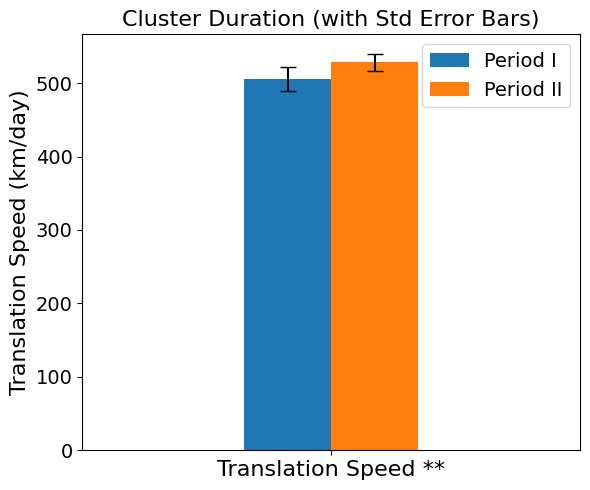

In [45]:
import numpy as np
import matplotlib.pyplot as plt

DU = np.array(c3speed).flatten()
data_period1 = DU[:17]
data_period2 = DU[17:]

mean1 = np.mean(data_period1)
mean2 = np.mean(data_period2)
std1 = np.std(data_period1, ddof=1) / np.sqrt(len(data_period1))
std2 = np.std(data_period2, ddof=1) / np.sqrt(len(data_period2))

labels = ['Translation Speed **']
x = np.arange(len(labels))

width = 0.35  # 柱宽设置得非常细

fig, ax = plt.subplots(figsize=(6,5))

bars1 = ax.bar(x - width/2, mean1, width, yerr=std1, capsize=6, 
               label='Period I',  linewidth=1.2)
bars2 = ax.bar(x + width/2, mean2, width, yerr=std2, capsize=6, 
               label='Period II', linewidth=1.2)

ax.set_ylabel("Translation Speed (km/day)", fontsize=16)
ax.tick_params(axis='y', labelsize=14)
ax.set_title("Cluster Duration (with Std Error Bars)", fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=16)
ax.legend(fontsize=14)

# ✅ 关键：人为拉宽 x 轴区间，使柱子不被自动撑大
ax.set_xlim(-1, 1)

plt.tight_layout()
plt.savefig("Figure S3d.pdf", transparent=True)
plt.show()


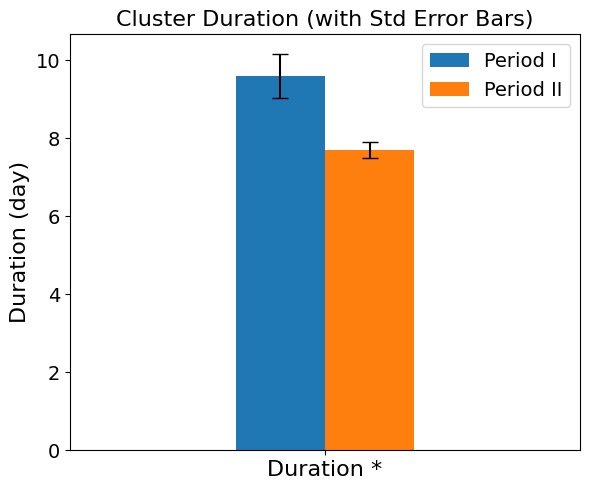

In [46]:
import numpy as np
import matplotlib.pyplot as plt

DU = c3duration
data_period1 = DU[:17]
data_period2 = DU[17:]

mean1 = np.mean(data_period1)
mean2 = np.mean(data_period2)
std1 = np.std(data_period1, ddof=1) / np.sqrt(len(data_period1))
std2 = np.std(data_period2, ddof=1) / np.sqrt(len(data_period2))

labels = ['Duration *']
x = np.arange(len(labels))

width = 0.35  # 柱宽设置得非常细

fig, ax = plt.subplots(figsize=(6,5))

bars1 = ax.bar(x - width/2, mean1, width, yerr=std1, capsize=6, 
               label='Period I',  linewidth=1.2)
bars2 = ax.bar(x + width/2, mean2, width, yerr=std2, capsize=6, 
               label='Period II', linewidth=1.2)

ax.set_ylabel("Duration (day)", fontsize=16)
ax.tick_params(axis='y', labelsize=14)
ax.set_title("Cluster Duration (with Std Error Bars)", fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=16)
ax.legend(fontsize=14)

# ✅ 关键：人为拉宽 x 轴区间，使柱子不被自动撑大
ax.set_xlim(-1, 1)

plt.tight_layout()
plt.savefig("Figure S3c.pdf", transparent=True)
plt.show()


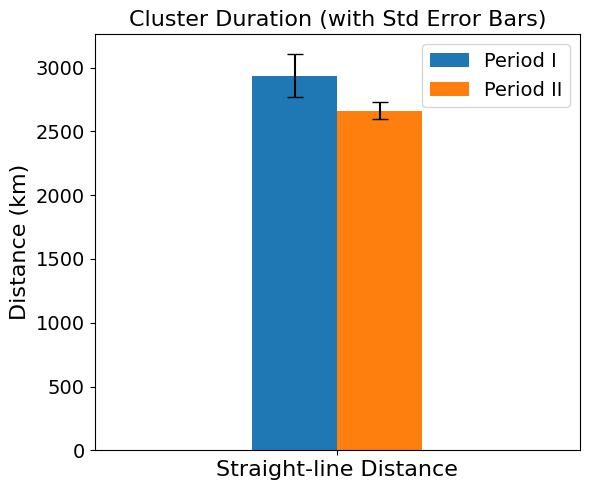

In [47]:
import numpy as np
import matplotlib.pyplot as plt

DU = linedistance
data_period1 = DU[:17]
data_period2 = DU[17:]

mean1 = np.mean(data_period1)
mean2 = np.mean(data_period2)
std1 = np.std(data_period1, ddof=1) / np.sqrt(len(data_period1))
std2 = np.std(data_period2, ddof=1) / np.sqrt(len(data_period2))

labels = ['Straight-line Distance']
x = np.arange(len(labels))

width = 0.35  # 柱宽设置得非常细

fig, ax = plt.subplots(figsize=(6,5))

bars1 = ax.bar(x - width/2, mean1, width, yerr=std1, capsize=6, 
               label='Period I',  linewidth=1.2)
bars2 = ax.bar(x + width/2, mean2, width, yerr=std2, capsize=6, 
               label='Period II', linewidth=1.2)

ax.set_ylabel("Distance (km)", fontsize=16)
ax.tick_params(axis='y', labelsize=14)
ax.set_title("Cluster Duration (with Std Error Bars)", fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=16)
ax.legend(fontsize=14)

# ✅ 关键：人为拉宽 x 轴区间，使柱子不被自动撑大
ax.set_xlim(-1, 1)

plt.tight_layout()
plt.savefig("Figure S3b.pdf", transparent=True)
plt.show()


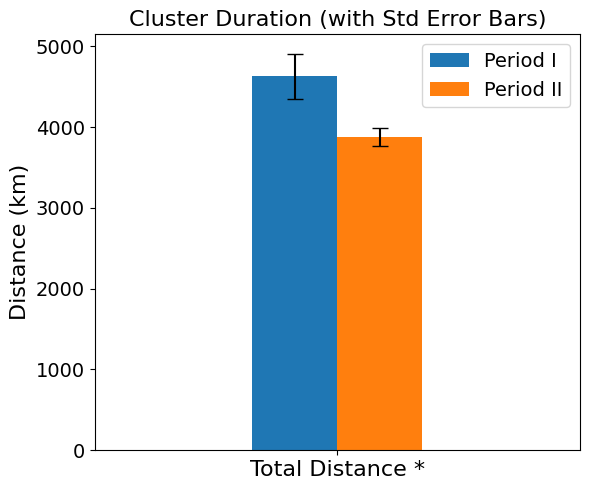

In [48]:
import numpy as np
import matplotlib.pyplot as plt

DU = totaldistance
data_period1 = DU[:17]
data_period2 = DU[17:]

mean1 = np.mean(data_period1)
mean2 = np.mean(data_period2)
std1 = np.std(data_period1, ddof=1) / np.sqrt(len(data_period1))
std2 = np.std(data_period2, ddof=1) / np.sqrt(len(data_period2))

labels = ['Total Distance *']
x = np.arange(len(labels))

width = 0.35 # 柱宽设置得非常细

fig, ax = plt.subplots(figsize=(6,5))

bars1 = ax.bar(x - width/2, mean1, width, yerr=std1, capsize=6, 
               label='Period I',  linewidth=1.2)
bars2 = ax.bar(x + width/2, mean2, width, yerr=std2, capsize=6, 
               label='Period II', linewidth=1.2)

ax.set_ylabel("Distance (km)", fontsize=16)
ax.tick_params(axis='y', labelsize=14)
ax.set_title("Cluster Duration (with Std Error Bars)", fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=16)
ax.legend(fontsize=14)

# ✅ 关键：人为拉宽 x 轴区间，使柱子不被自动撑大
ax.set_xlim(-1, 1)

plt.tight_layout()
plt.savefig("Figure S3a.pdf", transparent=True)
plt.show()
